# **Phân loại Naive Bayes với Scikit-Learn**

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

### **Iris Dataset**

Trong nhiệm vụ này, chúng ta phải phân loại 3 loại hoa Iris dựa trên chiều dài và chiều rộng của cánh hoa và đài hoa của chúng. Những loài đó bao gồm Setosa, Versicolor và Virginica được mã hóa lần lượt với 0, 1, 2

Tập dữ liệu phân loại hoa Iris có sẵn trong gói scikit-learn. Tải và sử nó cho kinh ngiệm của chúng ta, bạn có thể ... nó theo code sau:


In [2]:
# Tải tập dữ liệu Iris
iris = datasets.load_iris()
class_names = iris.target_names

# Chuyển về định dạng pandas cho dễ xử 
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
iris_df['target'] = iris.target


In [3]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# Chia tập dữ liệu vào tập huấn luyện và tập thử nghiệm
X_train, X_test, y_train, y_test = train_test_split(
    iris_df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']],
    iris_df['target'],
    test_size = 0.2,
    random_state = 2021
)

### **Mô hình và kết quả**

Trong thực hành này, chúng ta xây dựng một mô hình phân lại Naiva Bayes để phân loại 3 lài hoa Iris. Chúng ta giả sử chiều dài của đài hoa và cánh hoa theo phân phối chuẩn. Vì thế chúng ta có thể huấn luyện Gaussian Naive Bayes như sau:

In [7]:
# import Naive Bayes
# Trong trường hợp này, ta giả sử những đặc trưng theo phân phối chuẩn
NB = GaussianNB()

# Huấn luyện mô hình Naive Bayes
NB.fit(X_train, y_train)
print('Training accuracy: {:.2f}'.format(NB.score(X_train, y_train)))

# Đánh giá mô hình trên tập thử nghiệm
y_predict = NB.predict(X_test)
print('Accuracy thử nghiệm NB: {:.2f}'.format(NB.score(X_test, y_test)))

Training accuracy: 0.97
Accuracy thử nghiệm NB: 0.93


Sau khi huấn luyện, mô hình của chúng ta đạt 93% accuracy trong tập thử nghiệm

### **Trực quan kết quả**

Mô hình của chúng ta thì rất tốt để phân loại sự đặc biệt của hoa Iris. Để tim fkieesm prediction, chúng ta sử dụng Principal Component Analysis (PCA) để làm giảm ....

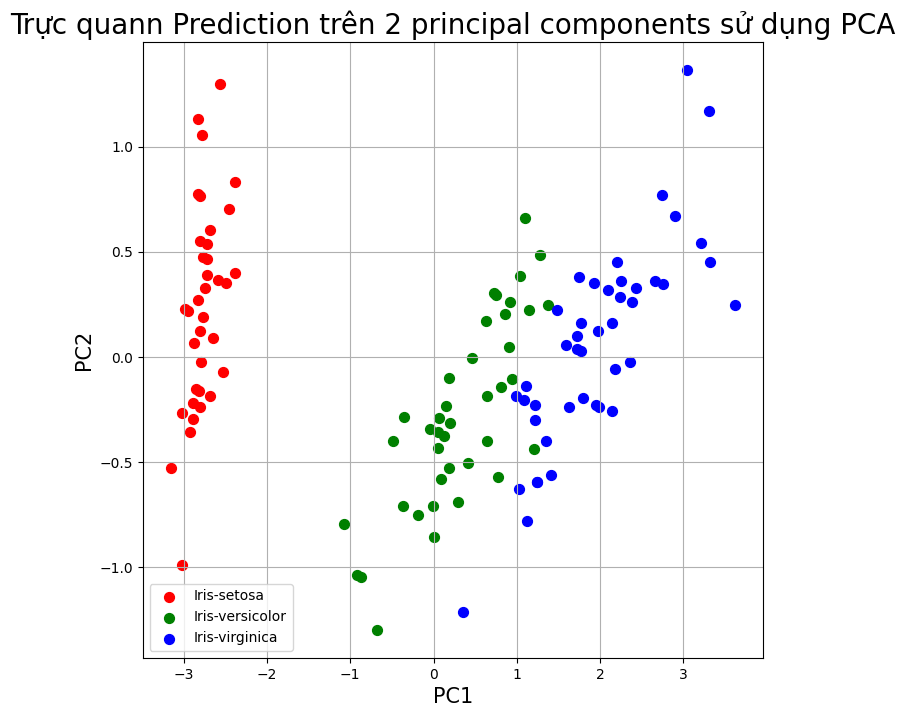

In [9]:
# Trực quan
from sklearn.decomposition import PCA
pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(X_train)

principalDf = pd.DataFrame(data = principalComponents, columns = ['PC1', 'PC2'])
finalDf = pd.concat([principalDf, y_train.reset_index(drop = True)], axis = 1)

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1, 1, 1)
ax.set_xlabel('PC1', fontsize = 15)
ax.set_ylabel('PC2', fontsize = 15)
ax.set_title('Trực quann Prediction trên 2 principal components sử dụng PCA', fontsize = 20)

targets = [0, 1, 2]
targets_2_desc = {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
colors = ['r', 'g', 'b']

for target, color in zip(targets, colors):
    indicesToKeep = finalDf['target'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'PC1'],
            finalDf.loc[indicesToKeep, 'PC2'],
            c = color,
            s = 50,
    label = targets_2_desc[target])
ax.legend()
ax.grid()

### **Kết luận**

Trong trường hợp này, chúng ta sử dụng mô hình bayes để phân loại 3 loài hoa Iris dựa trên chiều dài và chiều rộng của đài hoa và cánh hoa của chúng. accuracy đạt được 93% trong tập thử nghiệm